# Read the output of genZWPusingCylMaps.

## Simiar to readZWPs that read the outputs based on the main .fits file (not already cylindrically projected via DRM)
## The output data are not smoothed so most of the information from the 1D correlation can be retained. Smoothing can be applied here and parameters can be varied to generate the best fit for the final profile.

### The .npz files contain ['wind_prof_raw', 'date_list', 'delta_t_arr', 'crit_lat'].

In [1]:
import planetmapper
import matplotlib
# matplotlib.use('Qt5Agg')
# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math
from astropy.io import fits
import time
from scipy.signal import correlate
import scipy as sp
import datetime
import csv
import os
import glob
import pandas as pd

# main class where these functions are dumped:
from zonalwindfunctions import ZWP_Class

print(matplotlib.get_backend())


module://matplotlib_inline.backend_inline


In [3]:
long_res, lat_res = 360, 180
long_array, lat_array = np.linspace(360, 0,long_res), np.linspace(-90, 90,lat_res)
long_array_hi, lat_array_hi = np.linspace(360, 0,long_res*2), np.linspace(-90, 90,lat_res*2)
R_J = 71492e3 # m
R_J_p = 66854e3 # m

def DeleteElement(index_to_exclude):
    '''
    Useful to delete specific wind fields. Based on discretion; documentation is advised.
    '''
    del corr1D_list[index_to_exclude]
    del corr1D_err_list[index_to_exclude]
    del corr1D_fwhm_list[index_to_exclude]
    
    del corr_slide_list[index_to_exclude]
    del corr_slide_err_list[index_to_exclude]
    del corr_slide_fwhm_list[index_to_exclude]

    del lat_array_used[index_to_exclude]
    del long_array_use[index_to_exclude]

    del margin_applied_in_func_shifted[index_to_exclude]
    
    del date_list[index_to_exclude]
    del delta_t_list[index_to_exclude]
    del crit_lat_list[index_to_exclude]
    del pair_name_list[index_to_exclude]


In [7]:

year = '2016'
output_path = '/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/' + year + '/'
output_file_list = glob.glob(output_path + '*.npz')

# output_file_list = [f for f in output_file_list if '2024nov' not in f]

for f in output_file_list:
    print(f)

print(year)
print('Number of pairs originally: ', len(output_file_list))



/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016may11_jcf0057500592_jcf0003100048.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016may11_jcf0053300544_jcf0003100048.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016may11_jcf0072300740_jcf0000100008.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016nov1_jcf0022700356_jcf0003700060.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016may11_jcf0057500592_jcf0000100008.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016may11_jcf0072300740_jcf0003100048.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016may11_jcf0053300544_jcf0000100008.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016may11_jcf0072300740_jcf0017700194.npz
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016may11_jcf0072300740_jc

In [8]:
'''
shifted_f1=[shifted_f1], shifted_f2=[shifted_f1], long_shift_applied=[long_shift_applied],
wind_slide=[rough_wind_full], w_slide_err=[err_velocity_slide], w_slide_fwhm=[fwhm_array_slide],
wind_noslide=[zwp_5microns], w_noslide_err=[err_velocity], w_npslide_fwhm=[fwhm_array],
lat_array_used=[lat_array_use], long_array_use=[long_array_use], margin_applied_in_func_shifted=[margin_applied_in_func_shifted],
date_list = date_meta_list[test_i], pair_names = pair_names, delta_t_arr = [delta_t], crit_lat=[critical_lat]
'''
print(np.load(output_file_list[0]))

NpzFile '/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2016/2016may11_jcf0057500592_jcf0003100048.npz' with keys: shifted_f1, shifted_f2, long_shift_applied, wind_slide, w_slide_err...


In [10]:
corr1D_list = []
corr1D_err_list = []
corr1D_fwhm_list = []
corr_slide_list = []
corr_slide_err_list = []
corr_slide_fwhm_list = []
lat_array_used = []
long_array_use = []
margin_applied_in_func_shifted = []
date_list = []
delta_t_list = []
crit_lat_list = []
pair_name_list = []

for f in output_file_list:
    npzfile = np.load(f)
    
    # Correlation with no sliding window
    corr1D_list.append(npzfile['wind_noslide'])
    corr1D_err_list.append(npzfile['w_noslide_err'])
    corr1D_fwhm_list.append(npzfile['w_npslide_fwhm'])

    # Correlation with 50˚ sliding window
    corr_slide_list.append(npzfile['wind_slide'])
    corr_slide_err_list.append(npzfile['w_slide_err'])
    corr_slide_fwhm_list.append(npzfile['w_slide_fwhm'])

    # Specific latitude array that was used - removes the need to interpolate later
    lat_array_used.append(npzfile['lat_array_used'])
    long_array_use.append(npzfile['long_array_use'])

    margin_applied_in_func_shifted.append(npzfile['margin_applied_in_func_shifted'])

    
    date_list.append(npzfile['date_list'])
    delta_t_list.append(npzfile['delta_t_arr'])
    crit_lat_list.append(npzfile['crit_lat'])
    pair_name_list.append(npzfile['pair_names'])

    print(npzfile['pair_names'], npzfile['date_list'], npzfile['delta_t_arr'], 'shape: ', len(npzfile['wind_noslide'][0]))

# comment out if you want to include everything:
# print()
# index_to_exclude = -3 # feb image jc187221 had a lot of shaking, so this will exclude it from the final ZWP
# print('Excluding: ', pair_name_list[index_to_exclude], date_list[index_to_exclude], delta_t_list[index_to_exclude])
# DeleteElement(index_to_exclude)

print(len(corr1D_list), len(corr_slide_list))





['jcf0057500592.cmap.gz' 'jcf0003100048.cmap.gz'] ['2016-05-11T08:47:33.92773' '2016-05-12T05:18:23.76172'] [73849.833991] shape:  360
['jcf0053300544.cmap.gz' 'jcf0003100048.cmap.gz'] ['2016-05-11T08:39:34.17773' '2016-05-12T05:18:23.76172'] [74329.583991] shape:  360
['jcf0072300740.cmap.gz' 'jcf0000100008.cmap.gz'] ['2016-05-11T09:56:21.39062' '2016-05-12T05:08:57.45703'] [69156.066411] shape:  360
['jcf0022700356.cmap.gz' 'jcf0003700060.cmap.gz'] ['2016-11-01T20:53:38.92188' '2016-11-02T17:10:07.61719'] [72988.695309] shape:  360
['jcf0057500592.cmap.gz' 'jcf0000100008.cmap.gz'] ['2016-05-11T08:47:33.92773' '2016-05-12T05:08:57.45703'] [73283.529301] shape:  360
['jcf0072300740.cmap.gz' 'jcf0003100048.cmap.gz'] ['2016-05-11T09:56:21.39062' '2016-05-12T05:18:23.76172'] [69722.371101] shape:  360
['jcf0053300544.cmap.gz' 'jcf0000100008.cmap.gz'] ['2016-05-11T08:39:34.17773' '2016-05-12T05:08:57.45703'] [73763.279301] shape:  360
['jcf0072300740.cmap.gz' 'jcf0017700194.cmap.gz'] ['201

In [ ]:
# index_to_exclude = 2 # removes the ['jc183201.cmap.fits.gz' 'jc329353.cmap.fits.gz'] pair

# print('Excluding: ', pair_name_list[index_to_exclude], date_list[index_to_exclude], delta_t_list[index_to_exclude])
# DeleteElement(index_to_exclude)

# print()
# for p in range(len(pair_name_list)):
#     print(p, pair_name_list[p], date_list[p], delta_t_list[p], 'shape: ', len(corr1D_list[p][0]))


Excluding:  ['jc183201.cmap.fits.gz' 'jc329353.cmap.fits.gz'] ['2024-08-16T19:50:05.20312' '2024-08-17T16:02:25.58594'] [72740.38282]


In [11]:
# index_to_exclude = 9 # removes the ['jc815843.cmap.fits.gz' 'jc329353.cmap.fits.gz'] pair

# print('Excluding: ', pair_name_list[index_to_exclude], date_list[index_to_exclude], delta_t_list[index_to_exclude])
# DeleteElement(index_to_exclude)

# # print()
# # for p in range(len(pair_name_list)):
# #     print(p, pair_name_list[p], date_list[p], delta_t_list[p], 'shape: ', len(corr1D_list[p][0]))


In [12]:
print(corr_slide_list[0][0][:, 0].shape, corr1D_list[0].shape, len(corr1D_list), len(corr_slide_err_list))

(360,) (1, 360) 11 11


In [ ]:
# smooth the profiles but retain their inhomogeneity (different latitudinal resolutions)
corr1D_list_smooth_inhomog = []
corr1D_err_list_smooth_inhomog = []

# with 50˚ sliding window:
corr_list_smooth_inhomog = []
corr_err_list_smooth_inhomog = []


for pair in range(len(corr1D_list)):
    # full latitude
    corr1D_list_smooth_inhomog.append(ZWP_Class.getSmoothedProfile(corr1D_list[pair][0], lat_array_used[pair][0], 7, 2))
    corr1D_err_list_smooth_inhomog.append(ZWP_Class.getSmoothedProfile(corr1D_err_list[pair][0], lat_array_used[pair][0], 7, 2))

for pair in range(len(corr_slide_list)):
    # with sliding window for the pair (f): [1, # of latitudes, # of slides that occurred]
    corr_list_smoothed_in_long = np.zeros((len(lat_array_used[pair][0]), corr_slide_list[pair].shape[-1]))
    # first, smooth out the longitudinally dependent profiles
    for w in range(corr_slide_list[pair].shape[-1]):
        corr_list_smoothed_in_long[:, w] = ZWP_Class.getSmoothedProfile(corr_slide_list[pair][0][:, w], lat_array_used[pair][0], 7, 3)
    # now take the average over the sliding window axis to get a smooth 1D profile for the pair
    corr_list_smooth_inhomog.append(np.mean(corr_list_smoothed_in_long, axis=1))
    corr_err_list_smooth_inhomog.append(ZWP_Class.getSmoothedProfile(corr_slide_err_list[pair][0], lat_array_used[pair][0], 7, 3))

# now make the smoothed profiles homogenous so that they share the same base resolutions
corr1D_list_smooth_homog = []
corr1D_err_list_smooth_homog = []
corr_list_smooth_homog = []
corr_err_list_smooth_homog = []
for pair in range(len(corr1D_list_smooth_inhomog)):
    if len(corr1D_list_smooth_inhomog[pair]) == 180:
        corr1D_list_smooth_homog.append(corr1D_list_smooth_inhomog[pair])
        corr1D_err_list_smooth_homog.append(corr1D_err_list_smooth_inhomog[pair])
        corr_list_smooth_homog.append(corr_list_smooth_inhomog[pair])
        corr_err_list_smooth_homog.append(corr_err_list_smooth_inhomog[pair])
    elif len(corr1D_list_smooth_inhomog[pair]) == 360:
        corr1D_list_smooth_homog.append(np.interp(lat_array, lat_array_hi, corr1D_list_smooth_inhomog[pair]))
        corr1D_err_list_smooth_homog.append(np.interp(lat_array, lat_array_hi, corr1D_err_list_smooth_inhomog[pair]))
        corr_list_smooth_homog.append(np.interp(lat_array, lat_array_hi, corr_list_smooth_inhomog[pair]))
        corr_err_list_smooth_homog.append(np.interp(lat_array, lat_array_hi, corr_err_list_smooth_inhomog[pair]))

print(len(corr1D_list_smooth_homog[1]))

# make into iterable array:
corr1D_list_smooth_homog_arr     = np.asarray(corr1D_list_smooth_homog)
corr1D_err_list_smooth_homog_arr = np.asarray(corr1D_err_list_smooth_homog)
corr_list_smooth_homog_arr       = np.asarray(corr_list_smooth_homog)
corr_err_list_smooth_homog_arr   = np.asarray(corr_err_list_smooth_homog)

print(corr1D_list_smooth_homog_arr.shape)
print(corr1D_err_list_smooth_homog_arr.shape)
print(corr_list_smooth_homog_arr.shape)
print(corr_err_list_smooth_homog_arr.shape)

180
(15, 180)
(15, 180)
(15, 180)
(15, 180)


In [22]:
# corr1D_list = np.asarray(corr1D_list)
# corr1D_array_smoothed = np.zeros(corr1D_list[:, 0, :].shape)

# for i in range(len(corr1D_list)):
#     corr1D_array_smoothed[i, :] = getSmoothedProfile(corr1D_list[i, 0, :], 7, 2)

noslide_mean_2024_ZWP = np.mean(corr1D_list_smooth_homog_arr, axis=0)
noslide_std_2024_ZWP = np.mean(corr1D_err_list_smooth_homog_arr, axis=0) # no need to use std here as the error list is the real error estimate

slide_mean_2024_ZWP = np.mean(corr_list_smooth_homog_arr, axis=0)
slide_std_2024_ZWP = np.mean(corr_err_list_smooth_homog_arr, axis=0) 

print(noslide_mean_2024_ZWP.shape, slide_mean_2024_ZWP.shape)
# print(corr1D_list[:, 0, :].shape)
# print(corr1D_array_smoothed.shape)

(180,) (180,)


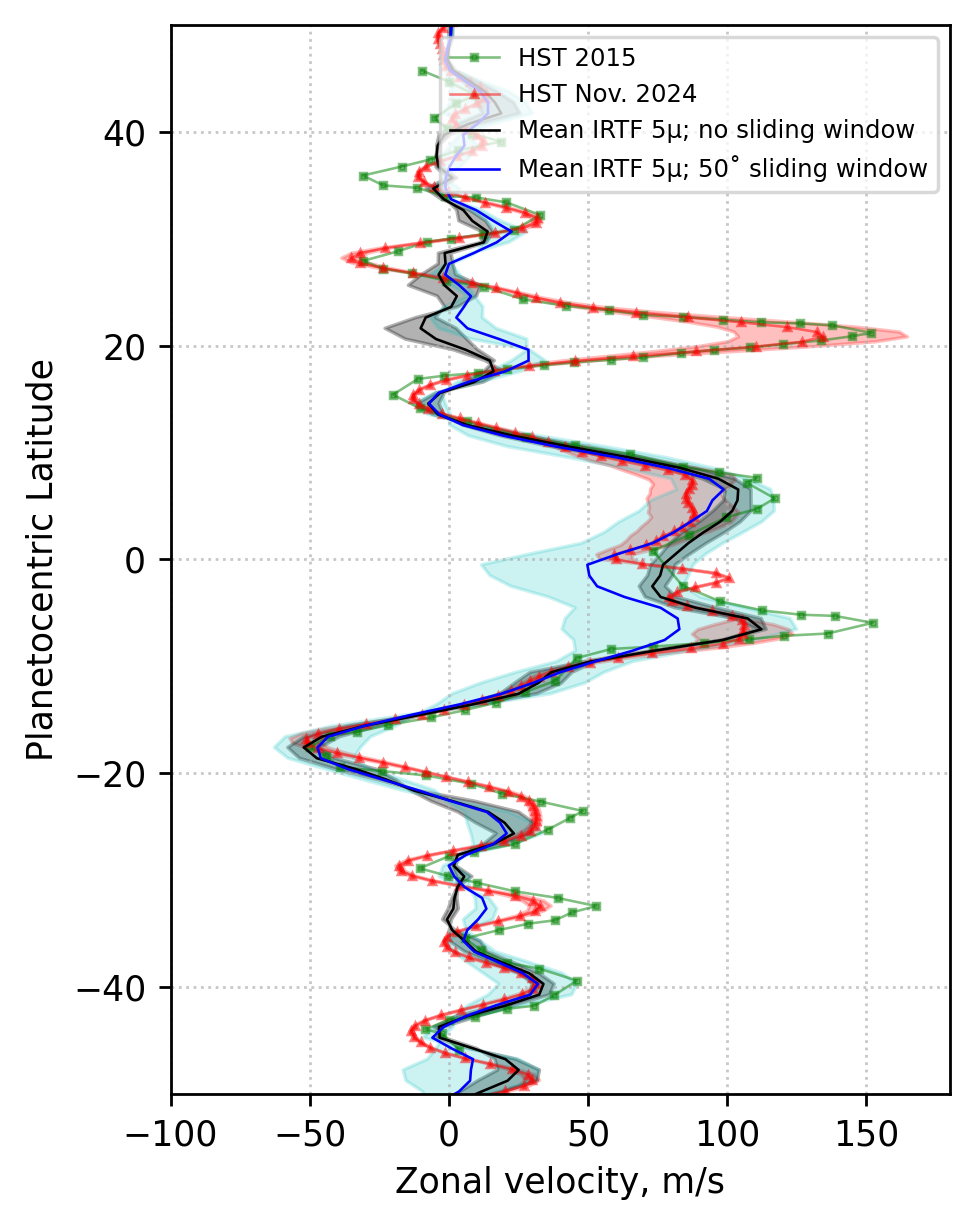

In [23]:

hst_wind_1D = np.genfromtxt('Simon+2015_ZWP_HST.csv', delimiter=",", dtype=None, encoding=None, names=True)
# opal_nov_2024 = np.genfromtxt('OPAL/2024nov_jup_502.xlsx', delimiter=",", dtype=None, encoding=None, names=True)
opal_nov_2024_df = pd.read_excel('OPAL/2024nov_jup_502.xlsx')
opal_nov_2024_error_mag = opal_nov_2024_df['FMZW']*opal_nov_2024_df['ERROR']/100
y_lim_range = 50

# convert HST planetographic latitudes to planetocentric
centric_lat_HST = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, opal_nov_2024_df['LAT']))
centric_lat_HST_2015 = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, hst_wind_1D['y']))

c_arr = plt.cm.hsv(np.linspace(0.1, 0.9, corr1D_list_smooth_homog_arr.shape[0]))

# [0, -3] for Oct. Both are about the same, as expected.
%matplotlib inline

plt.figure(dpi=250, figsize=(4,5))
# for i in [0, -3]:
# for i in range(corr1D_list_smooth_homog_arr.shape[0]):
#     plt.plot(corr1D_list_smooth_homog_arr[i], lat_array, color=c_arr[i], lw=0.5, alpha=0.9)#, label=date_list[i][0]+'\n'+date_list[i][1])
#     plt.plot(corr_list_smooth_homog_arr[i], lat_array, color=c_arr[i], lw=0.5, alpha=0.9, ls=':')

plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='g', marker='s', ms=2, lw=0.75, alpha=0.5, label='HST 2015')
plt.plot(opal_nov_2024_df['FMZW'][::5], centric_lat_HST[::5], color='r', marker='^', ms=2, lw=0.75, alpha=0.5, label='HST Nov. 2024')
plt.fill_betweenx(centric_lat_HST[::5], opal_nov_2024_df['FMZW'][::5]-opal_nov_2024_error_mag[::5], opal_nov_2024_df['FMZW'][::5]+opal_nov_2024_error_mag[::5], color='red', alpha=0.25)

plt.plot(noslide_mean_2024_ZWP, lat_array, color='k', lw=0.75, label='Mean IRTF 5µ; no sliding window')
plt.fill_betweenx(lat_array, noslide_mean_2024_ZWP-noslide_std_2024_ZWP, 
                  noslide_mean_2024_ZWP+noslide_std_2024_ZWP, color='k', alpha=0.3)

plt.plot(slide_mean_2024_ZWP, lat_array, color='b', lw=0.75, label='Mean IRTF 5µ; 50˚ sliding window')
plt.fill_betweenx(lat_array, slide_mean_2024_ZWP-slide_std_2024_ZWP, 
                  slide_mean_2024_ZWP+slide_std_2024_ZWP, color='c', alpha=0.2)


plt.ylim(-y_lim_range, y_lim_range)
plt.xlim(-100, 180)
plt.grid(True, 'both', ls=':', alpha=0.7)
plt.legend(loc='upper right', framealpha=0.75, fontsize='7')#, bbox_to_anchor=(1.8, 1))
plt.xlabel('Zonal velocity, m/s'), plt.ylabel('Planetocentric Latitude')
plt.tight_layout()
plt.show()

In [24]:
opal_nov_2024_df[:]['LAT']

0      -90.0
1      -89.9
2      -89.8
3      -89.7
4      -89.6
        ... 
1795    89.5
1796    89.6
1797    89.7
1798    89.8
1799    89.9
Name: LAT, Length: 1800, dtype: float64

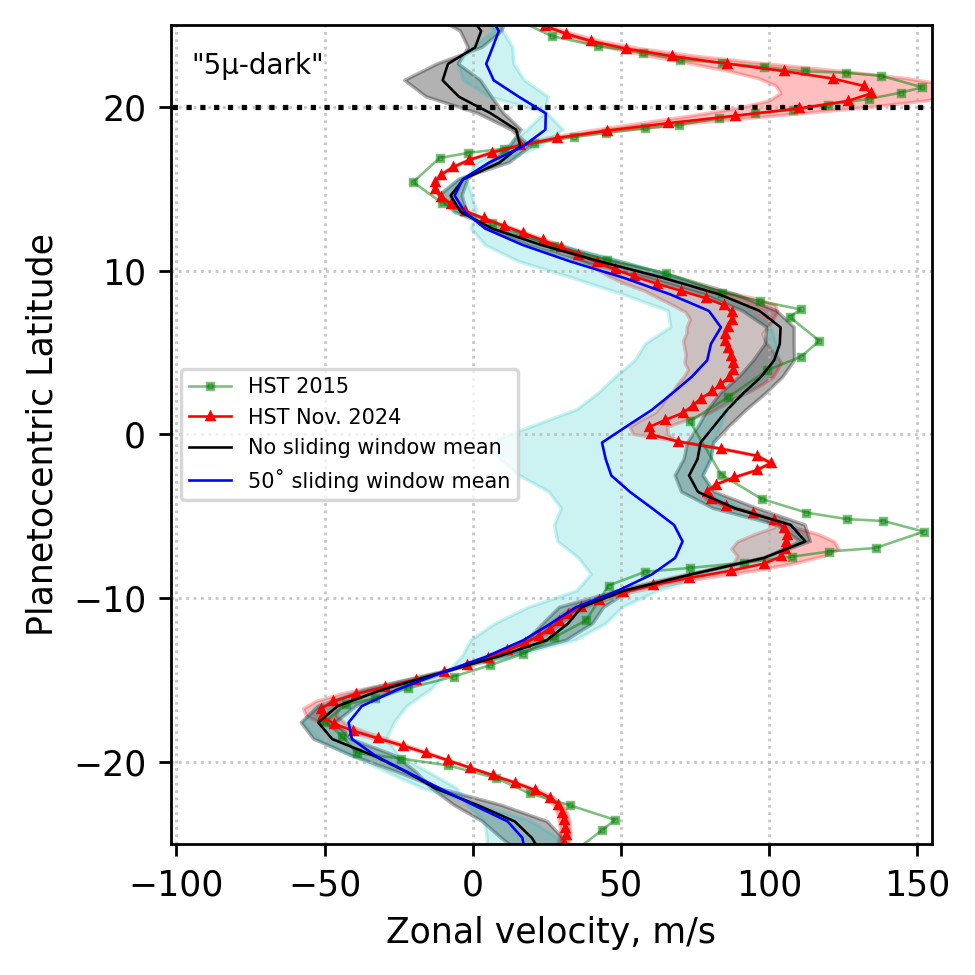

In [251]:
y_lim_range = 25

%matplotlib inline

plt.figure(figsize=(4,4), dpi=250)
plt.hlines(20, -120, 200, color='k', ls=':')
plt.text(-95, 22, '"5µ-dark"', fontsize=8)

# for i in range(corr1D_list_smooth_homog_arr.shape[0]):
#     plt.plot(corr1D_list_smooth_homog_arr[i], lat_array, color=c_arr[i], lw=0.5, alpha=0.75)#, label=date_list[i][0]+'\n'+date_list[i][1])

plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='g', marker='s', ms=2, lw=0.75, alpha=0.5, label='HST 2015')
plt.plot(opal_nov_2024_df['FMZW'][::5], centric_lat_HST[::5], color='r', marker='^', ms=2, lw=0.75, label='HST Nov. 2024')
plt.fill_betweenx(centric_lat_HST[::5], opal_nov_2024_df['FMZW'][::5]-opal_nov_2024_error_mag[::5], opal_nov_2024_df['FMZW'][::5]+opal_nov_2024_error_mag[::5], color='red', alpha=0.25)

plt.plot(noslide_mean_2024_ZWP, lat_array, color='k', lw=0.75, label='No sliding window mean')
plt.fill_betweenx(lat_array, noslide_mean_2024_ZWP-noslide_std_2024_ZWP, 
                  noslide_mean_2024_ZWP+noslide_std_2024_ZWP, color='k', alpha=0.3)

plt.plot(slide_mean_2024_ZWP, lat_array, color='b', lw=0.75, label='50˚ sliding window mean')
plt.fill_betweenx(lat_array, slide_mean_2024_ZWP-slide_std_2024_ZWP, 
                  slide_mean_2024_ZWP+slide_std_2024_ZWP, color='c', alpha=0.2)

plt.ylim(-y_lim_range, y_lim_range)
plt.xlim(-102, 155)
plt.grid(True, 'both', ls=':', alpha=0.7)
# plt.legend(bbox_to_anchor=(1.8, 1), loc='upper right', framealpha=0.75, fontsize='7')
plt.legend(loc='center left', framealpha=0.75, fontsize='6')
plt.xlabel('Zonal velocity, m/s'), plt.ylabel('Planetocentric Latitude')
plt.tight_layout()
plt.show()